In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
import pandas as pd

df = pd.read_csv("abc_employee.csv")
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


In [41]:
import numpy as np

df['Height'] = np.random.randint(150, 181, size=len(df))

In [42]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    int32  
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int32(1), int64(3), object(4)
memory usage: 30.5+ KB


Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

In [27]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,180,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,172,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,177,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,151,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,155,231,NaN,5000000.0


### Data Preprocessing

- The 'Height' column contained incorrect data, so it was replaced with random values between 150 and 180.
- The dataset was checked for missing values using `isnull()`.
- Missing values were found in some columns like 'College' and 'Salary'.
- The dataset is now ready for analysis.

## Analysis Tasks

In [28]:
team_count = df['Team'].value_counts()
team_percent = (team_count / len(df)) * 100
print(team_percent)

Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
New York Knicks           3.493450
Milwaukee Bucks           3.493450
Brooklyn Nets             3.275109
Portland Trail Blazers    3.275109
Oklahoma City Thunder     3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Miami Heat                3.275109
Charlotte Hornets         3.275109
Atlanta Hawks             3.275109
San Antonio Spurs         3.275109
Houston Rockets           3.275109
Boston Celtics            3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Sacramento Kings          3.275109
Phoenix Suns              3.275109
Los Angeles Lakers        3.275109
Los Angeles Clippers      3.275109
Golden State Warriors     3.275109
Toronto Raptors           3.275109
Philadelphia 76ers        3.275109
Dallas Mavericks          3.275109
Orlando Magic  

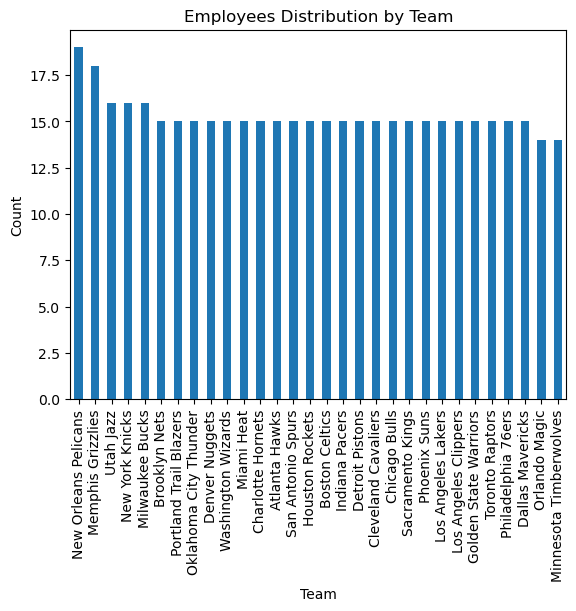

In [29]:
team_count.plot(kind='bar')
plt.title("Employees Distribution by Team")
plt.xlabel("Team")
plt.ylabel("Count")
plt.show()

In [30]:
position_count = df['Position'].value_counts()
print(position_count)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


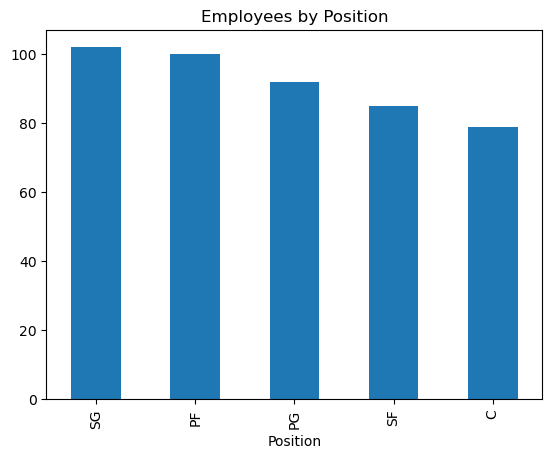

In [31]:
position_count.plot(kind='bar')
plt.title("Employees by Position")
plt.show()

In [32]:
bins = [20, 25, 30, 35, 40, 45]
labels = ['20-25', '25-30', '30-35', '35-40', '40-45']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_group = df['AgeGroup'].value_counts()

print(age_group)

AgeGroup
20-25    179
25-30    167
30-35     68
35-40     23
40-45      0
Name: count, dtype: int64


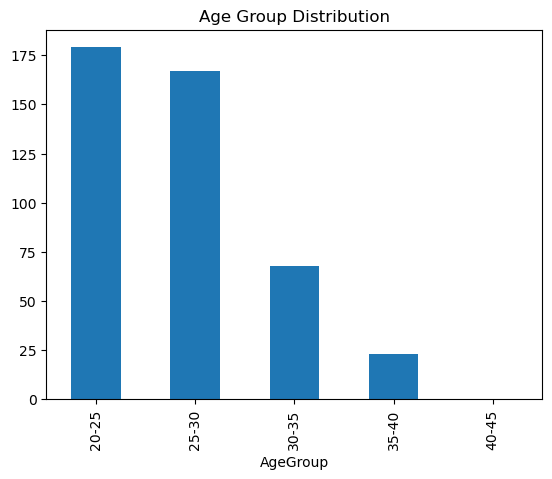

In [33]:
age_group.plot(kind='bar')
plt.title("Age Group Distribution")
plt.show()

In [34]:
team_salary = df.groupby('Team')['Salary'].sum()
position_salary = df.groupby('Position')['Salary'].sum()

print(team_salary.idxmax())
print(position_salary.idxmax())

Cleveland Cavaliers
C


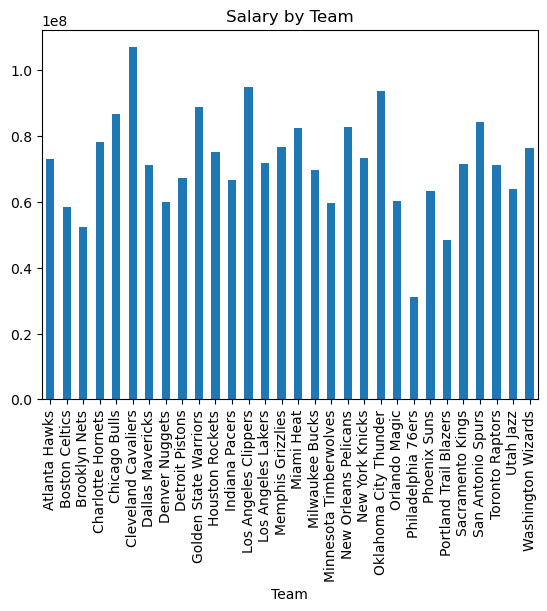

In [35]:
team_salary.plot(kind='bar')
plt.title("Salary by Team")
plt.show()

In [36]:
correlation = df['Age'].corr(df['Salary'])
print(correlation)

0.21400941226570974


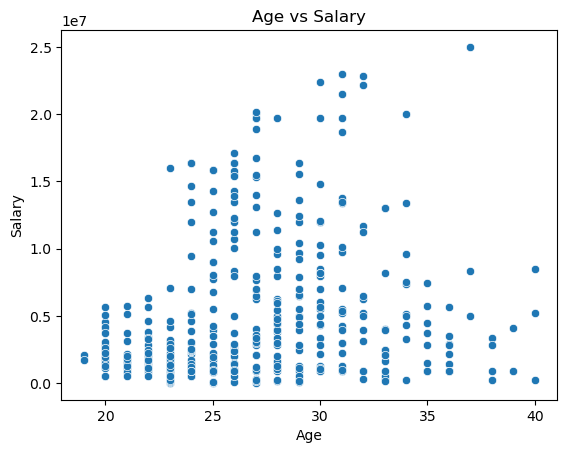

In [37]:
sns.scatterplot(x=df['Age'], y=df['Salary'])
plt.title("Age vs Salary")
plt.show()

## Data Insights

- Most employees belong to the New Orleans Pelicans team.
- The SG position has the highest number of employees.
- The predominant age group is 20-25.
- The Cleveland Cavaliers team has the highest salary expenditure.
- There is a positive correlation between age and salary.
- As age increases, salary increases.